# Module 2: Emotion Classifier


We used `Mental-RoBERTa` for this mental health RAG system because its domain-specific pre-training on millions of peer-support text logs allows it to capture subtle psychological cues, implicit descriptions of distress, and contextual nuances far more accurately than general-purpose language models

## Install & Import Libraries

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup
)
from datasets import load_dataset

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Using device: {device}")
if device.type == "cuda":
    print(f"   GPU: {torch.cuda.get_device_name(0)}")

✅ Using device: cuda
   GPU: NVIDIA GeForce GTX 1650


## Configuration
All hyperparameters in one place for easy tuning

In [2]:
# ── Configuration ──────────────────────────────────────────
MODEL_NAME = "mental/mental-roberta-base"
MAX_LEN = 128
BATCH_SIZE = 32
EPOCHS = 4
LR = 2e-5
WARMUP_RATIO = 0.1
SEED = 42

# Emotion labels
ID2LABEL = {0: "sadness", 1: "joy", 2: "love", 3: "anger", 4: "fear", 5: "surprise"}
LABEL2ID = {v: k for k, v in ID2LABEL.items()}
NUM_CLASSES = len(ID2LABEL)

# Reproducibility
torch.manual_seed(SEED)
np.random.seed(SEED)

print(f"Model: {MODEL_NAME}")
print(f"Max length: {MAX_LEN} tokens")
print(f"Batch size: {BATCH_SIZE}")
print(f"Epochs: {EPOCHS}")
print(f"LR: {LR}")
print(f"Classes: {list(ID2LABEL.values())}")

Model: mental/mental-roberta-base
Max length: 128 tokens
Batch size: 32
Epochs: 4
LR: 2e-05
Classes: ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']


## Load Dataset

In [3]:
# Load from HuggingFace
dataset = load_dataset("dair-ai/emotion")

train_df = dataset["train"].to_pandas()
val_df = dataset["validation"].to_pandas()
test_df = dataset["test"].to_pandas()

# Map integer labels to emotion names
train_df["emotion"] = train_df["label"].map(ID2LABEL)
val_df["emotion"] = val_df["label"].map(ID2LABEL)
test_df["emotion"] = test_df["label"].map(ID2LABEL)

print(f"Train size: {len(train_df):,}")
print(f"Validation size: {len(val_df):,}")
print(f"Test size: {len(test_df):,}")
train_df.head(10)

Train size: 16,000
Validation size: 2,000
Test size: 2,000


,text,label,emotion
0,i didnt feel humiliated,0,sadness
1,i can go from feeling so hopeless to so damned...,0,sadness
2,im grabbing a minute to post i feel greedy wrong,3,anger
3,i am ever feeling nostalgic about the fireplac...,2,love
4,i am feeling grouchy,3,anger
5,ive been feeling a little burdened lately wasn...,0,sadness
6,ive been taking or milligrams or times recomme...,5,surprise
7,i feel as confused about life as a teenager or...,4,fear
8,i have been with petronas for years i feel tha...,1,joy
9,i feel romantic too,2,love


## Data Exploration

Class distribution (train):
emotion
joy         5362
sadness     4666
anger       2159
fear        1937
love        1304
surprise     572
Name: count, dtype: int64


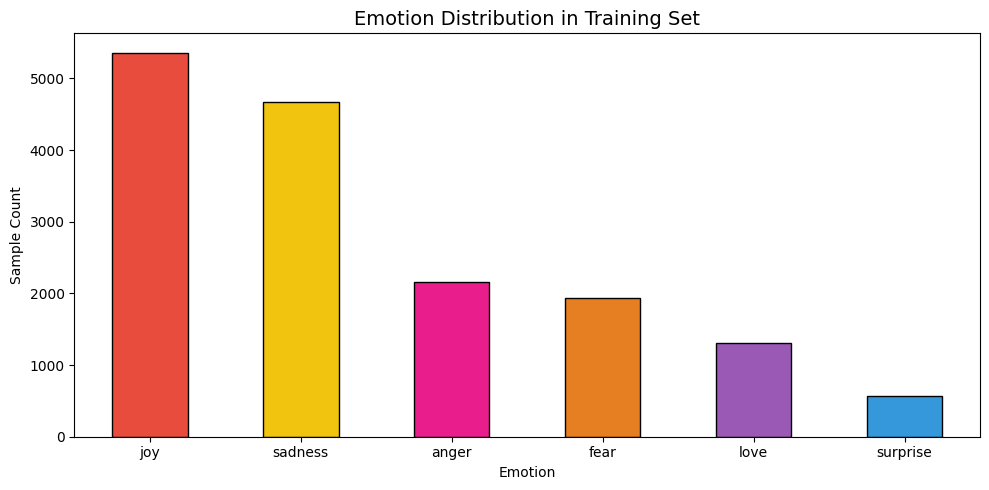


Note: Dataset is imbalanced — sadness and joy dominate.
This may affect recall on minority classes like 'surprise' and 'love'.


In [ ]:
# Class distribution
class_counts = train_df["emotion"].value_counts()
print("Class distribution (train):")
print(class_counts)

# Plot
colors = ["#e74c3c", "#f1c40f", "#e91e8c", "#e67e22", "#9b59b6", "#3498db"]
plt.figure(figsize=(10, 5))
class_counts.plot(kind="bar", color=colors, edgecolor="black")
plt.title("Emotion Distribution in Training Set", fontsize=14)
plt.xlabel("Emotion")
plt.ylabel("Sample Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print("\nNote: Dataset is imbalanced — sadness and joy dominate.")
print("This may affect recall on minority classes like 'surprise' and 'love'.")

In [ ]:
# Sample texts per emotion
print("Sample texts per emotion:\n")
for emotion in ID2LABEL.values():
    sample = train_df[train_df["emotion"] == emotion]["text"].iloc[0]
    print(f"[{emotion:>10}]: {sample}")
print()

# Text length distribution
train_df["text_len"] = train_df["text"].apply(lambda x: len(x.split()))
print(f"Average text length: {train_df['text_len'].mean():.1f} words")
print(f"Max text length: {train_df['text_len'].max()} words")
print(f"Min text length: {train_df['text_len'].min()} words")

Sample texts per emotion:

[   sadness]: i didnt feel humiliated
[       joy]: i have been with petronas for years i feel that petronas has performed well and made a huge profit
[      love]: i am ever feeling nostalgic about the fireplace i will know that it is still on the property
[     anger]: im grabbing a minute to post i feel greedy wrong
[      fear]: i feel as confused about life as a teenager or as jaded as a year old man
[  surprise]: ive been taking or milligrams or times recommended amount and ive fallen asleep a lot faster but i also feel like so funny

Average text length: 19.2 words
Max text length: 66 words
Min text length: 2 words


## Tokenization & Dataset Class

We wrap the data in a PyTorch `Dataset` class so the `DataLoader` can efficiently batch it during training.

In [4]:
from huggingface_hub import notebook_login

notebook_login()

In [5]:
# Load tokenizer
print(f"Loading tokenizer: {MODEL_NAME}")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print("Tokenizer loaded")

# Quick tokenization test
sample = "I feel so anxious and overwhelmed today"
tokens = tokenizer(sample, return_tensors="pt")
print(f"\nSample: '{sample}'")
print(f"Token IDs: {tokens['input_ids']}")
print(f"Token count: {tokens['input_ids'].shape[1]}")

Loading tokenizer: mental/mental-roberta-base
Tokenizer loaded

Sample: 'I feel so anxious and overwhelmed today'
Token IDs: tensor([[    0,   100,   619,    98, 13473,     8, 13203,   452,     2]])
Token count: 9


In [6]:
class EmotionDataset(Dataset):
    """
    PyTorch Dataset for emotion classification.
    Tokenizes text on-the-fly and returns tensors ready for the model.
    """
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts = texts.tolist()
        self.labels = labels.tolist()
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            max_length=self.max_len,
            padding="max_length",
            truncation=True,
            return_tensors="pt"
        )
        return {
            "input_ids": encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "label": torch.tensor(self.labels[idx], dtype=torch.long)
        }


# Create datasets
train_dataset = EmotionDataset(train_df["text"], train_df["label"], tokenizer, MAX_LEN)
val_dataset = EmotionDataset(val_df["text"], val_df["label"], tokenizer, MAX_LEN)
test_dataset = EmotionDataset(test_df["text"], test_df["label"], tokenizer, MAX_LEN)

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")

Train batches: 500
Validation batches: 63
Test batches: 63


## Load Model — Mental-RoBERTa

`AutoModelForSequenceClassification` automatically adds a classification head (linear layer → softmax) on top of the pretrained RoBERTa backbone.

In [7]:
print(f"Loading model: {MODEL_NAME}")

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_CLASSES,
    id2label=ID2LABEL,
    label2id=LABEL2ID
)

model = model.to(device)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print("Model loaded ")

Loading model: mental/mental-roberta-base


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: mental/mental-roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.weight    | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Total parameters: 124,650,246
Trainable parameters: 124,650,246
Model loaded 


## 7. Training Setup

In [ ]:
total_steps = len(train_loader) * EPOCHS
warmup_steps = int(total_steps * WARMUP_RATIO)

# Optimizer — AdamW is standard for transformer fine-tuning
optimizer = AdamW(model.parameters(), lr=LR, weight_decay=0.01)

# Learning rate scheduler — linearly warms up then linearly decays
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

# Loss function
criterion = nn.CrossEntropyLoss()

print(f"Total training steps: {total_steps}")
print(f"Warmup steps: {warmup_steps}")
print(f"Optimizer: AdamW (lr={LR}, weight_decay=0.01)")
print(f"Scheduler: Linear warmup + decay")

Total training steps: 2000
Warmup steps: 200
Optimizer: AdamW (lr=2e-05, weight_decay=0.01)
Scheduler: Linear warmup + decay


## 8. Training Loop

In [ ]:
def train_epoch(model, loader, optimizer, scheduler, criterion, device):
    """One full pass over the training data."""
    model.train()
    total_loss, correct, total = 0, 0, 0

    for batch in loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["label"].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        loss = criterion(outputs.logits, labels)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()
        preds = outputs.logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return total_loss / len(loader), correct / total


def evaluate(model, loader, criterion, device):
    """Evaluate model on a given dataloader."""
    model.eval()
    total_loss, correct, total = 0, 0, 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for batch in loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["label"].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            loss = criterion(outputs.logits, labels)

            total_loss += loss.item()
            preds = outputs.logits.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return total_loss / len(loader), correct / total, all_preds, all_labels


print("Training functions defined")

Training functions defined


In [ ]:
# ── Training ───────────────────────────────────────────────
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
best_val_acc  = 0
best_model_path = "models/mental_roberta_emotion.pt"
os.makedirs("models", exist_ok=True)

print("Starting training...\n")
print(f"{'Epoch':>6} | {'Train Loss':>10} | {'Train Acc':>9} | {'Val Loss':>8} | {'Val Acc':>7}")
print("-" * 55)

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = train_epoch(model, train_loader, optimizer, scheduler, criterion, device)
    val_loss, val_acc, _, _ = evaluate(model, val_loader, criterion, device)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(f"{epoch:>6} | {train_loss:>10.4f} | {train_acc:>8.4f}% | {val_loss:>8.4f} | {val_acc:>6.4f}%")

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), best_model_path)
        print(f"         ↑ Best model saved (val_acc={val_acc:.4f})")

print(f"\nTraining complete: Best val accuracy: {best_val_acc:.4f}")

Starting training...

 Epoch | Train Loss | Train Acc | Val Loss | Val Acc
-------------------------------------------------------
     1 |     0.7930 |   0.6998% |   0.2368 | 0.9160%
         ↑ Best model saved (val_acc=0.9160)
     2 |     0.1965 |   0.9237% |   0.1758 | 0.9300%
         ↑ Best model saved (val_acc=0.9300)
     3 |     0.1345 |   0.9449% |   0.1475 | 0.9350%
         ↑ Best model saved (val_acc=0.9350)
     4 |     0.1007 |   0.9521% |   0.1333 | 0.9375%
         ↑ Best model saved (val_acc=0.9375)

Training complete: Best val accuracy: 0.9375


## 9. Training Curves

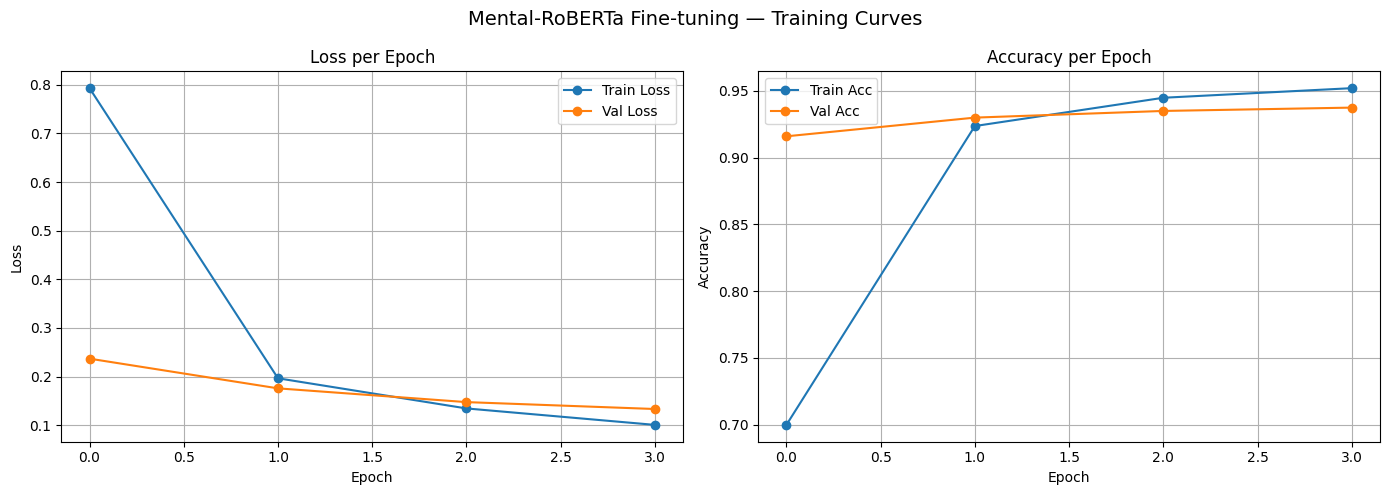

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss
ax1.plot(history["train_loss"], label="Train Loss", marker="o")
ax1.plot(history["val_loss"],   label="Val Loss",   marker="o")
ax1.set_title("Loss per Epoch")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.legend()
ax1.grid(True)

# Accuracy
ax2.plot(history["train_acc"], label="Train Acc", marker="o")
ax2.plot(history["val_acc"],   label="Val Acc",   marker="o")
ax2.set_title("Accuracy per Epoch")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy")
ax2.legend()
ax2.grid(True)

plt.suptitle("Mental-RoBERTa Fine-tuning — Training Curves", fontsize=14)
plt.tight_layout()
plt.show()

## 10. Evaluation on Test Set

In [ ]:
# Load best model weights
model.load_state_dict(torch.load(best_model_path, map_location=device))

# Evaluate on test set
test_loss, test_acc, test_preds, test_labels = evaluate(model, test_loader, criterion, device)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")
print()
print("=" * 60)
print("Classification Report (Test Set):")
print("=" * 60)
print(classification_report(
    test_labels,
    test_preds,
    target_names=list(ID2LABEL.values())
))

Test Loss: 0.1608
Test Accuracy: 0.9285 (92.85%)

Classification Report (Test Set):
              precision    recall  f1-score   support

     sadness       0.96      0.97      0.96       581
         joy       0.97      0.93      0.95       695
        love       0.79      0.91      0.85       159
       anger       0.93      0.92      0.93       275
        fear       0.88      0.91      0.89       224
    surprise       0.75      0.73      0.74        66

    accuracy                           0.93      2000
   macro avg       0.88      0.89      0.89      2000
weighted avg       0.93      0.93      0.93      2000



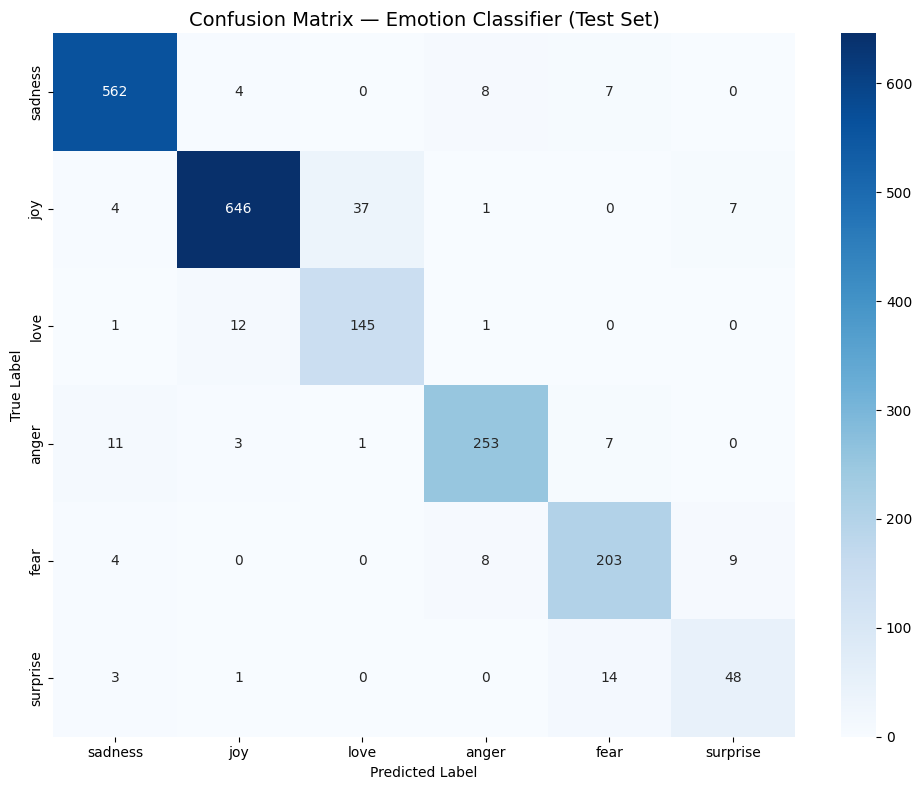

In [ ]:
# Confusion Matrix
cm = confusion_matrix(test_labels, test_preds)
emotion_names = list(ID2LABEL.values())

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=emotion_names,
    yticklabels=emotion_names
)
plt.title("Confusion Matrix — Emotion Classifier (Test Set)", fontsize=14)
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.show()

## 11. Save Full Model & Tokenizer

In [ ]:
# Save model + tokenizer together for easy loading in deployment
SAVE_DIR = "models/emotion_classifier"
os.makedirs(SAVE_DIR, exist_ok=True)

model.save_pretrained(SAVE_DIR)
tokenizer.save_pretrained(SAVE_DIR)

print("Model and tokenizer saved ")
print(f"  → {SAVE_DIR}/")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model and tokenizer saved 
  → ./2- Emotion Classifier Model/Mahmoud Saqr/models/emotion_classifier/


## 12. Inference Function
This is what all other modules and the deployment script will import and call.

In [9]:
def classify_emotion(text: str) -> dict:
    """
    Classifies the emotion of the input text.

    Args:
        text (str): User input text.

    Returns:
        dict: {
            'emotion': str,   # predicted emotion label
            'confidence': float  # confidence score (0-1)
        }
    """
    # Lazy load — only once
    if not hasattr(classify_emotion, "_model"):
        SAVE_DIR = "models/emotion_classifier"
        classify_emotion._tokenizer = AutoTokenizer.from_pretrained(SAVE_DIR)
        classify_emotion._model = AutoModelForSequenceClassification.from_pretrained(SAVE_DIR)
        classify_emotion._model = classify_emotion._model.to(device)
        classify_emotion._model.eval()

    # Tokenize
    encoding = classify_emotion._tokenizer(
        text,
        max_length=MAX_LEN,
        padding="max_length",
        truncation=True,
        return_tensors="pt"
    )

    input_ids = encoding["input_ids"].to(device)
    attention_mask = encoding["attention_mask"].to(device)

    # Predict
    with torch.no_grad():
        outputs = classify_emotion._model(input_ids=input_ids, attention_mask=attention_mask)
        probs = torch.softmax(outputs.logits, dim=1)
        pred_id = probs.argmax(dim=1).item()
        confidence = probs[0][pred_id].item()

    return {
        "emotion": ID2LABEL[pred_id],
        "confidence": round(confidence, 4)
    }


# ── Test the inference function ────────────────────────────
test_cases = [
    "I feel so hopeless and empty, nothing brings me joy anymore.",
    "I'm so excited about my progress today, feeling great!",
    "I'm terrified of what might happen next.",
    "I love spending time with my family, it warms my heart.",
    "This situation makes me so angry, I can't stand it.",
    "I didn't expect that at all, completely caught off guard."
]

print("Inference test results:")
print("-" * 65)
for text in test_cases:
    result = classify_emotion(text)
    print(f"Got: {result['emotion']:>10} ({result['confidence']:.2%}) | {text[:40]}")

Inference test results:
-----------------------------------------------------------------


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Got:    sadness (99.86%) | I feel so hopeless and empty, nothing br
Got:        joy (99.88%) | I'm so excited about my progress today, 
Got:       fear (99.76%) | I'm terrified of what might happen next.
Got:        joy (86.20%) | I love spending time with my family, it 
Got:      anger (99.69%) | This situation makes me so angry, I can'
Got:   surprise (74.54%) | I didn't expect that at all, completely 
